<a href="https://colab.research.google.com/github/rajkgoel/AW-Internet-Sales1/blob/master/CO2%20Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.0 - Question
================

Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

Case-study data captures information about vehicle models, categories, engine size/type/transmission, fuel type, fuel economy, fuel consumption behaviour (on different terrains), and CO2 emission.

Based on the vehicle type/category/engine-size, it may consume different volume of fuel, and thus it may result in different CO2 emmission for each.

Larger/heavier classes (SUVs, vans, pickups), and vehicles with higher engine capcity may often emit more CO2 than smaller classes.

Fuel type matters because fuels have different carbon intensity and engine efficiency (e.g., Ethanol, Premium, Natural Gas fuel can differ from a Regular Gasoline, or Diesel).

Transmission can affect efficiency (gear count/type/CVT), which indirectly shifts CO₂.

Make/model capture hidden factors (aerodynamics, tuning, hybrid systems, weight) that can explain differences even within the same class/engine size.



---



2.0 - Question
================

Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

In [64]:
import pandas as pd
# 2.1 Check the consistency and quality of the dataset

# Load data
df = pd.read_csv(r"/CO2_Emissions.csv")

# Display basic info
print("Shape (rows, cols):", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print("\nMissing values report:")
display(pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct}))

# Duplicate rows
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")


Shape (rows, cols): (7385, 12)

Columns:
['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

Data types:
Make                                 object
Model                                object
Vehicle Class                        object
Engine Size(L)                      float64
Cylinders                             int64
Transmission                         object
Fuel Type                            object
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

Missing values report:


,Missing Count,Missing %
Make,0,0.0
Model,0,0.0
Vehicle Class,0,0.0
Engine Size(L),0,0.0
Cylinders,0,0.0
Transmission,0,0.0
Fuel Type,0,0.0
Fuel Consumption City (L/100 km),0,0.0
Fuel Consumption Hwy (L/100 km),0,0.0
Fuel Consumption Comb (L/100 km),0,0.0



Duplicate rows: 1103


In [65]:
# 2.2 - Remove the duplicates from dataset

# Find duplicate records
total_rows = len(df)
removable_dup_rows = df.duplicated().sum()

print(f"Total rows: {total_rows}")
print(f"Removable duplicate rows: {removable_dup_rows}")

# Inspect sample duplicate records
dup_sample = df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(5)
display(dup_sample)

# Clean dataset by removing duplicates
print("=" * 100)
df_clean = df.drop_duplicates().copy()
print(f"\nOriginal Shape: {df.shape}")
print(f"Shape after dropping duplicates: {df_clean.shape}")

print("=" * 100)

Total rows: 7385
Removable duplicate rows: 1103


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3313,ACURA,ILX,COMPACT,2.4,4,AM8,Z,9.4,6.8,8.2,34,192
4371,ACURA,ILX,COMPACT,2.4,4,AM8,Z,9.4,6.8,8.2,34,192
5454,ACURA,ILX,COMPACT,2.4,4,AM8,Z,9.9,7.0,8.6,33,199
6503,ACURA,ILX,COMPACT,2.4,4,AM8,Z,9.9,7.0,8.6,33,199
3316,ACURA,MDX HYBRID AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210



Original Shape: (7385, 12)
Shape after dropping duplicates: (6282, 12)


In [66]:
# 2.3 - Validate numeric types and value ranges

# Columns expected to be numeric
num_cols = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)",
    "CO2 Emissions(g/km)"
]

# Enforce numeric dtype (invalid parsing -> NaN)
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Dtypes after conversion:")
print(df_clean[num_cols].dtypes)

# Range checks
invalid_masks = {
    "engine_size_non_positive": df_clean["Engine Size(L)"] <= 0,
    "cylinders_non_positive": df_clean["Cylinders"] <= 0,
    "city_negative": df_clean["Fuel Consumption City (L/100 km)"] < 0,
    "hwy_negative": df_clean["Fuel Consumption Hwy (L/100 km)"] < 0,
    "comb_negative": df_clean["Fuel Consumption Comb (L/100 km)"] < 0,
    "mpg_non_positive": df_clean["Fuel Consumption Comb (mpg)"] <= 0,
    "co2_non_positive": df_clean["CO2 Emissions(g/km)"] <= 0,
}

invalid_summary = pd.Series(
    {k: int(v.sum()) for k, v in invalid_masks.items()},
    name="count"
    )
print("\nInvalid value summary:")
display(invalid_summary.to_frame())

print("\n Numeric columns data is found to be correct.")
print("=" * 100)


Dtypes after conversion:
Engine Size(L)                      float64
Cylinders                             int64
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

Invalid value summary:


,count
engine_size_non_positive,0
cylinders_non_positive,0
city_negative,0
hwy_negative,0
comb_negative,0
mpg_non_positive,0
co2_non_positive,0



 Numeric columns data is found to be correct.


In [67]:
# 2.4 - Standardize categorical values

import numpy as np

# 1) Trim spaces, collapse repeated spaces, uppercase for uniformity
category_cols = ["Make", "Model", "Vehicle Class", "Transmission", "Fuel Type"]
for col in category_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"\s+", " ", regex=True)
    )
df_clean["Transmission"] = (df_clean["Transmission"]
                            .str.upper()
                            .str.replace(" ", "", regex=False))


# 2) Normalize known fuel label variants -> code
fuel_variant_to_code = {
    "REGULAR GASOLINE": "X",
    "PREMIUM GASOLINE": "Z",
    "DIESEL": "D",
    "ETHANOL (E85)": "E",
    "NATURAL GAS": "N"
}
df_clean["Fuel Type"] = df_clean["Fuel Type"].replace(fuel_variant_to_code)

# 3) Decode abbreviations (interpretability)
fuel_code_map = {
    "X": "Regular Gasoline",
    "Z": "Premium Gasoline",
    "D": "Diesel",
    "E": "Ethanol (E85)",
    "N": "Natural Gas"
}
df_clean["Fuel Type Label"] = df_clean["Fuel Type"].map(fuel_code_map).fillna("Unknown")

# Transmission decode
df_clean["Transmission Type Code"] = (df_clean["Transmission"]
                                      .str.extract(r"^([A-Z]+)", expand=False))
df_clean["Transmission Gears"] = pd.to_numeric(
    df_clean["Transmission"].str.extract(r"(\d+)", expand=False),
    errors="coerce"
)
trans_type_map = {
    "A": "Automatic",
    "AS": "Automatic - Select Shift",
    "AV": "Continuously Variable (CVT)",
    "M": "Manual",
    "AM": "Automated Manual"
}
df_clean["Transmission Type Label"] = (df_clean["Transmission Type Code"]
                                       .map(trans_type_map).fillna("Unknown"))

# 5) Quick validation output
print("Unique Fuel Type codes:",
      sorted(df_clean["Fuel Type"].dropna().unique().tolist()))
print("Unique Transmission prefixes:",
      sorted(df_clean["Transmission Type Code"].dropna().unique().tolist()))
print("\nNulls in decoded fields:")
display(df_clean[
    ["Fuel Type Label", "Transmission Type Label", "Transmission Gears"]]
        .isna().sum().to_frame("null_count"))

display(df_clean[[
    "Make", "Model", "Vehicle Class", "Transmission", "Transmission Type Label",
    "Transmission Gears", "Fuel Type", "Fuel Type Label"
]].head(5))

df_clean.head()

Unique Fuel Type codes: ['D', 'E', 'N', 'X', 'Z']
Unique Transmission prefixes: ['A', 'AM', 'AS', 'AV', 'M']

Nulls in decoded fields:


,null_count
Fuel Type Label,0
Transmission Type Label,0
Transmission Gears,241


,Make,Model,Vehicle Class,Transmission,Transmission Type Label,Transmission Gears,Fuel Type,Fuel Type Label
0,ACURA,ILX,COMPACT,AS5,Automatic - Select Shift,5.0,Z,Premium Gasoline
1,ACURA,ILX,COMPACT,M6,Manual,6.0,Z,Premium Gasoline
2,ACURA,ILX HYBRID,COMPACT,AV7,Continuously Variable (CVT),7.0,Z,Premium Gasoline
3,ACURA,MDX 4WD,SUV - SMALL,AS6,Automatic - Select Shift,6.0,Z,Premium Gasoline
4,ACURA,RDX AWD,SUV - SMALL,AS6,Automatic - Select Shift,6.0,Z,Premium Gasoline


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Fuel Type Label,Transmission Type Code,Transmission Gears,Transmission Type Label
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,Premium Gasoline,AS,5.0,Automatic - Select Shift
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,Premium Gasoline,M,6.0,Manual
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,Premium Gasoline,AV,7.0,Continuously Variable (CVT)
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,Premium Gasoline,AS,6.0,Automatic - Select Shift
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,Premium Gasoline,AS,6.0,Automatic - Select Shift


3.0 - Question
===============

Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.


In [68]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

target = "CO2 Emissions(g/km)"

# Choose features
feature_cols = ["Make", "Vehicle Class", "Engine Size(L)", "Cylinders",
                "Transmission Type Code", "Transmission Gears",
                "Fuel Type", "Fuel Consumption City (L/100 km)",
                "Fuel Consumption Hwy (L/100 km)",
                "Fuel Consumption Comb (L/100 km)",
                "Fuel Consumption Comb (mpg)"]

X = df_clean[feature_cols].copy()
y = df_clean[target].copy()

# Mark categorical columns for LightGBM
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype("category")

print("Feature columns:", feature_cols)
print("Categorical columns:", cat_cols)
print("Target column:", target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train, categorical_feature=cat_cols)

pred = model.predict(X_test)

print("\nPrediction performance on test set:", pred)

# Feature importance
imp = (
    pd.DataFrame({
        "feature": X.columns, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(imp.head(15))

Feature columns: ['Make', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission Type Code', 'Transmission Gears', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']
Categorical columns: ['Make', 'Vehicle Class', 'Transmission Type Code', 'Fuel Type']
Target column: CO2 Emissions(g/km)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 651
[LightGBM] [Info] Number of data points in the train set: 5025, number of used features: 11
[LightGBM] [Info] Start training from score 250.806169

Prediction performance on test set: [312.20346133 243.84952658 295.66931078 ... 299.02466532 192.03024123
 193.86389459

,feature,importance
9,Fuel Consumption Comb (L/100 km),3069
8,Fuel Consumption Hwy (L/100 km),2504
7,Fuel Consumption City (L/100 km),2304
2,Engine Size(L),1387
0,Make,756
5,Transmission Gears,675
6,Fuel Type,522
1,Vehicle Class,503
3,Cylinders,135
4,Transmission Type Code,134


3.0 - Solution Summary

The LightGBM feature-importance results show that fuel-consumption variables are the strongest predictors of CO2 emissions.

CO2 emissions are driven primarily by direct fuel-consumption measures, with engine size and some vehicle-category/fuel-type/manufacturer effects contributing secondarily.

From the feature importance sequence, it can be inferred that fuel consumption is strongly influenced by engine size. A larger engine size typically leads to higher fuel consumption, which in turn results in greater CO2 emissions.


4.0 - Question
===============

Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

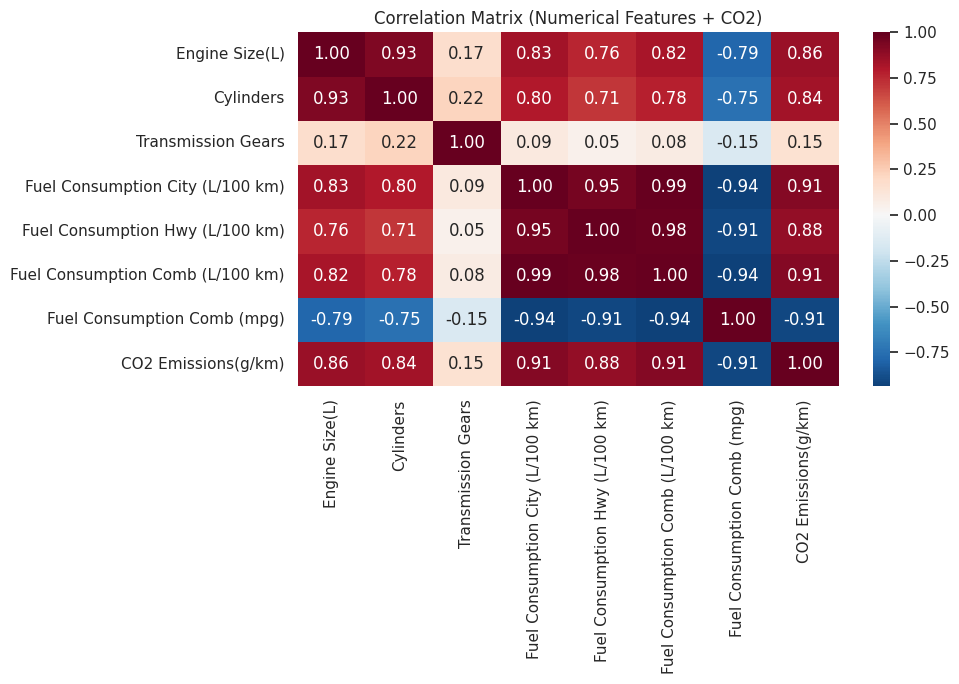

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

target = "CO2 Emissions(g/km)"
num_features = [
    "Engine Size(L)",
    "Cylinders",
    "Transmission Gears",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

plot_df = df_clean[num_features + [target]].dropna().copy()

# 1) Correlation heatmap
plt.figure(figsize=(10, 7))
corr = plot_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Matrix (Numerical Features + CO2)")
plt.tight_layout()
plt.show()


The correlation heatmap shows that CO2 emissions are most strongly related to fuel consumption metrics:

- Strong positive correlations with Fuel Consumption City/Hwy/Comb (L/100 km) (~0.88–0.91).
- Strong negative correlation with Fuel Consumption Comb (mpg) (~-0.91), which is expected since mpg is inversely related to L/100 km.
- Engine Size (0.86) and Cylinders (0.84) also have strong positive relationships with CO2.
- Transmission Gears has a weak relationship with CO2 (0.15).

Overall, the chart indicates that fuel-use intensity is the primary driver of CO2 emissions in this dataset.

5.0 - Question
==============

Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

In [70]:
# 5.1 - Compare emissions across fuel category

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target = "CO2 Emissions(g/km)"
fuel_col = "Fuel Type Label"

comp_df = df_clean[[fuel_col, target]].dropna().copy()

# Get the Emission for each fuel category
fuel_stats = (
    comp_df.groupby(fuel_col)[target]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

print("5.1 - CO2 Emissions statistics by fuel category:")
print("=" * 50)
display(fuel_stats.round(2))



5.1 - CO2 Emissions statistics by fuel category:


,count,mean,median,std
Fuel Type Label,,,,
Ethanol (E85),330,276.05,280.0,48.74
Premium Gasoline,2765,265.73,254.0,57.64
Regular Gasoline,3039,235.98,229.0,58.30
Diesel,147,235.24,243.0,41.91
Natural Gas,1,213.00,213.0,NaN


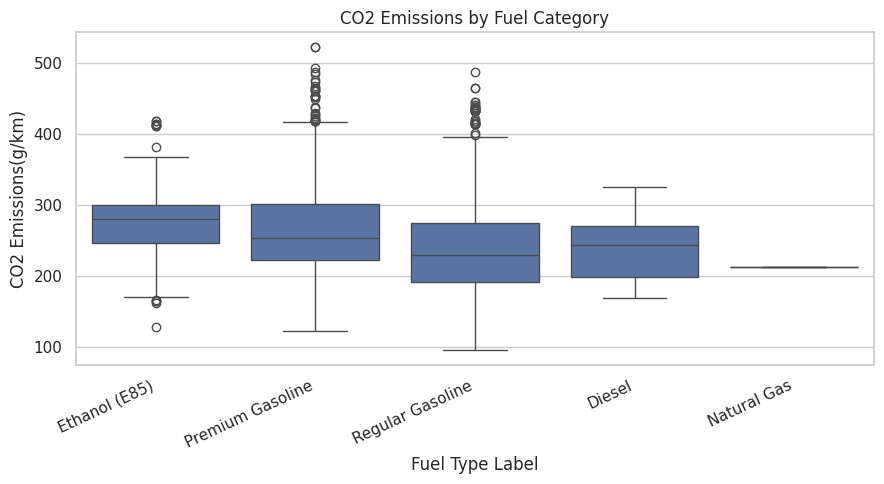

Key distinctions:
- Highest avg fuel-category emissions: Ethanol (E85) (276.0 g/km)
- Lowest avg fuel-category emissions : Natural Gas (213.0 g/km)


In [71]:
# Plot the graph for Fuel category comparison
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
order_fuel = fuel_stats.index.tolist()
sns.boxplot(data=comp_df, x=fuel_col, y=target, order=order_fuel)
plt.xticks(rotation=25, ha="right")
plt.title("CO2 Emissions by Fuel Category")
plt.tight_layout()
plt.show()

# Auto-find key distinctions
high_fuel = fuel_stats.index[0]
low_fuel = fuel_stats.index[-1]
high_fuel_mean = fuel_stats.iloc[0]["mean"]
low_fuel_mean = fuel_stats.iloc[-1]["mean"]

print("Key distinctions:")
print(f"- Highest avg fuel-category emissions: {high_fuel} ({high_fuel_mean:.1f} g/km)")
print(f"- Lowest avg fuel-category emissions : {low_fuel} ({low_fuel_mean:.1f} g/km)")

In [72]:
# 5.2 - Compare emissions across vehicle type
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target = "CO2 Emissions(g/km)"
vehicle_col = "Vehicle Class"

comp_df = df_clean[[vehicle_col, target]].dropna().copy()

vehicle_stats = (
    comp_df.groupby(vehicle_col)[target]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
)

print("\n5.2 - CO2 Emissions statistics by vehicle category:")
print("=" * 50)
display(vehicle_stats.head(10).round(2))



5.2 - CO2 Emissions statistics by vehicle category:


,count,mean,median,std
Vehicle Class,,,,
VAN - PASSENGER,66,397.21,414.0,42.27
VAN - CARGO,22,361.50,362.0,17.87
SUV - STANDARD,613,306.73,306.0,44.30
PICKUP TRUCK - STANDARD,475,301.61,298.0,31.04
TWO-SEATER,381,282.09,270.0,75.11
PICKUP TRUCK - SMALL,133,277.02,274.0,22.50
FULL-SIZE,508,264.41,262.0,55.78
MINIVAN,61,261.11,262.0,18.26
SUBCOMPACT,533,244.57,237.0,49.65


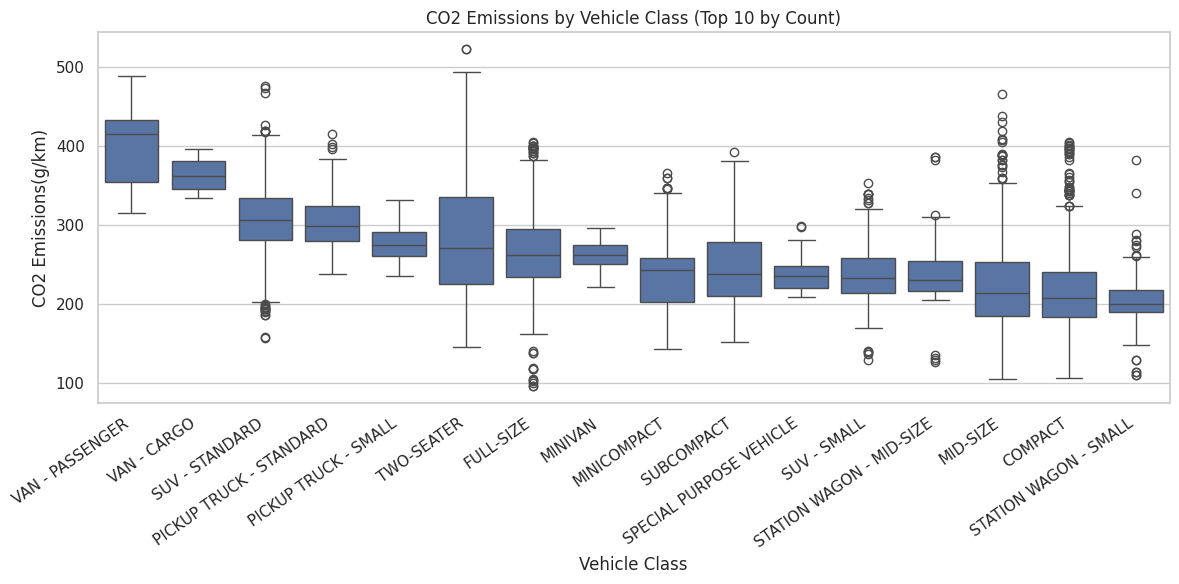

Key distinctions:
Highest avg vehicle-class emissions: VAN - PASSENGER (397.2 g/km)
Lowest avg vehicle-class emissions : STATION WAGON - SMALL (202.7 g/km)


In [73]:
# Vehicle class comparison
plt.figure(figsize=(12, 6))
order_vehicle = (
    comp_df.groupby(vehicle_col)[target].median().sort_values(ascending=False).index
)
sns.boxplot(data=comp_df, x=vehicle_col, y=target, order=order_vehicle)
plt.xticks(rotation=35, ha="right")
plt.title("CO2 Emissions by Vehicle Class (Top 10 by Count)")
plt.tight_layout()
plt.show()

# Auto-find key distinctions
high_vehicle = vehicle_stats.index[0]
low_vehicle = vehicle_stats.index[-1]
high_vehicle_mean = vehicle_stats.iloc[0]["mean"]
low_vehicle_mean = vehicle_stats.iloc[-1]["mean"]

print("=" * 100)
print("Key distinctions:")
print(f"Highest avg vehicle-class emissions: {high_vehicle} ({high_vehicle_mean:.1f} g/km)")
print(f"Lowest avg vehicle-class emissions : {low_vehicle} ({low_vehicle_mean:.1f} g/km)")
print("=" * 100)

6.0 - Question
===============

Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

In [74]:
import numpy as np
import pandas as pd

target = "CO2 Emissions(g/km)"

# Build peer groups using similar characteristics
d = df_clean[[
    "Make", "Model",
    "Vehicle Class", "Fuel Type Label", "Transmission Type Code",
    "Transmission Gears", "Cylinders", "Engine Size(L)",
    target
]].dropna().copy()

# Bin engine size so vehicles are compared to close engine sizes
d["engine_bin"] = (d["Engine Size(L)"] * 2).round() / 2  # Bin sizes aggregating into 0.5L bins

peer_cols = [
    "Vehicle Class", "Fuel Type Label", "Transmission Type Code",
    "Transmission Gears", "Cylinders", "engine_bin"
]

# Keep only peer groups with enough samples
d["peer_size"] = d.groupby(peer_cols)[target].transform("size")
d_peer = d[d["peer_size"] >= 5].copy()

# Outlier bounds within each peer group
peer_stats = d_peer.groupby(peer_cols)[target].agg(
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    **{"Median CO2 Emissions": "median"}
).reset_index()

peer_stats["iqr"] = peer_stats["q3"] - peer_stats["q1"]
peer_stats["low"] = peer_stats["q1"] - 1.5 * peer_stats["iqr"]
peer_stats["high"] = peer_stats["q3"] + 1.5 * peer_stats["iqr"]

# display(peer_stats.head(20))

d_peer = d_peer.merge(peer_stats, on=peer_cols, how="left")
d_peer["residual_vs_peer_median"] = d_peer[target] - d_peer["Median CO2 Emissions"]

d_peer["emission_flag"] = np.where(
    d_peer[target] > d_peer["high"], "High Outliers",
    np.where(d_peer[target] < d_peer["low"], "Low Outliers", "Normal")
)

print("Flag counts (within similar-characteristic peer groups):")
print(d_peer["emission_flag"].value_counts())

disp_cols = [
    "Make", "Model", "Vehicle Class", "Fuel Type Label", "Transmission Type Code",
    "Transmission Gears", "Cylinders", "Engine Size(L)", "engine_bin",
    "peer_size", target, "Median CO2 Emissions", "residual_vs_peer_median"
]


Flag counts (within similar-characteristic peer groups):
emission_flag
Normal           4959
High Outliers     101
Low Outliers       72
Name: count, dtype: int64


In [75]:
print("\nHighest emitters (vs similar vehicles):")
display(
    d_peer[d_peer["emission_flag"] == "High Outliers"][disp_cols]
    .sort_values("residual_vs_peer_median", ascending=False)
    .head(5)
)



Highest emitters (vs similar vehicles):


,Make,Model,Vehicle Class,Fuel Type Label,Transmission Type Code,Transmission Gears,Cylinders,Engine Size(L),engine_bin,peer_size,CO2 Emissions(g/km),Median CO2 Emissions,residual_vs_peer_median
3687,JEEP,GRAND CHEROKEE 4X4 TRACKHAWK,SUV - STANDARD,Premium Gasoline,A,8.0,8,6.2,6.0,12,413,329.5,83.5
4363,JEEP,GRAND CHEROKEE 4X4 TRACKHAWK,SUV - STANDARD,Premium Gasoline,A,8.0,8,6.2,6.0,12,413,329.5,83.5
3093,MERCEDES-BENZ,AMG GLC 43 4MATIC COUPE,SUV - SMALL,Premium Gasoline,A,9.0,6,3.0,3.0,5,353,272.0,81.0
613,MITSUBISHI,LANCER EVOLUTION,COMPACT,Premium Gasoline,AM,6.0,4,2.0,2.0,8,288,215.0,73.0
4814,BMW,X3 M,SUV - SMALL,Premium Gasoline,AS,8.0,6,3.0,3.0,33,339,267.0,72.0


In [76]:
print("\nLowest emitters (vs similar vehicles):")
display(
    d_peer[d_peer["emission_flag"] == "Low Outliers"][disp_cols]
    .sort_values("residual_vs_peer_median", ascending=True)
    .head(5)
)


Lowest emitters (vs similar vehicles):


,Make,Model,Vehicle Class,Fuel Type Label,Transmission Type Code,Transmission Gears,Cylinders,Engine Size(L),engine_bin,peer_size,CO2 Emissions(g/km),Median CO2 Emissions,residual_vs_peer_median
4900,FORD,EXPLORER HYBRID AWD,SUV - STANDARD,Regular Gasoline,AS,10.0,6,3.3,3.5,10,225,307.5,-82.5
5037,LEXUS,ES 300H,MID-SIZE,Regular Gasoline,AS,6.0,4,2.5,2.5,44,124,186.5,-62.5
4414,LAND ROVER,RANGE ROVER SPORT SUPERCHARGED,SUV - STANDARD,Premium Gasoline,AS,8.0,8,5.0,5.0,19,294,347.0,-53.0
86,BMW,Z4 SDRIVE35I,TWO-SEATER,Premium Gasoline,M,6.0,6,3.0,3.0,13,253,302.0,-49.0
4426,LEXUS,UX 250H,COMPACT,Regular Gasoline,AV,6.0,4,2.0,2.0,8,130,179.0,-49.0


Above two tables show the highest/lowest emitters in the same category. Category is defined by the following fields -
- engine_bin - Vehicles of similar engine capacity
- Vehicle Class
- Fuel Type Label
- Transmission Type Code
- Transmission Gears
- Cylinders Count

Vehicles that are emitting higher CO2 then the median in the similar category, higher CO₂ emissions are likely due to a combination of:
- Performance-oriented engine tuning
- Heavier vehicle weight
- SUV design and aerodynamics
- Power-focused drivetrain systems

Vehicles with the lowest CO₂ emissions within their peer groups seems to benefit from:
- Hybrid powertrains
- Advanced engine efficiency technologies
- Better aerodynamics
- Compact sizes
- Pptimized power-to-weight ratios

7.0 - Question
==============

Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "CO2 Emissions(g/km)"

# Use readable categorical labels for interpretability
feature_cols = [
    "Make",
    "Vehicle Class",
    "Fuel Type Label",
    "Transmission Type Label",
    "Engine Size(L)",
    "Cylinders",
    "Transmission Gears",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)"
]

data = df_clean[feature_cols + [target]].copy()

X = data[feature_cols]
y = data[target]

categorical_cols = ["Make", "Vehicle Class", "Fuel Type Label",
                    "Transmission Type Label"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# Split before fitting preprocessors (prevents leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # helps linear/distance-based models
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ],
    remainder="drop"
)

# Fit on train only, then transform train/test
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)


# Build interpretable feature names
cat_feature_names = (preprocessor.named_transformers_["cat"]["onehot"]
                     .get_feature_names_out(categorical_cols))
all_feature_names = list(numeric_cols) + list(cat_feature_names)

X_train_ready_df = pd.DataFrame(X_train_ready, columns=all_feature_names,
                                index=X_train.index)
X_test_ready_df = pd.DataFrame(X_test_ready, columns=all_feature_names,
                               index=X_test.index)

print("=" * 100)
print("Train shape:", X_train_ready_df.shape)
print("Test shape :", X_test_ready_df.shape)
print("\nSample transformed features:")
display(X_train_ready_df.head(5))
print("=" * 100)

Train shape: (5025, 74)
Test shape : (1257, 74)

Sample transformed features:


,Engine Size(L),Cylinders,Transmission Gears,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ACURA,Make_ALFA ROMEO,Make_ASTON MARTIN,...,Vehicle Class_VAN - PASSENGER,Fuel Type Label_Diesel,Fuel Type Label_Ethanol (E85),Fuel Type Label_Premium Gasoline,Fuel Type Label_Regular Gasoline,Transmission Type Label_Automated Manual,Transmission Type Label_Automatic,Transmission Type Label_Automatic - Select Shift,Transmission Type Label_Continuously Variable (CVT),Transmission Type Label_Manual
6622,-0.849467,-0.873804,0.987931,-0.729248,-0.378762,-0.612001,0.491449,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
106,0.913799,1.305285,0.987931,0.677156,0.322197,0.574381,-0.751812,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1503,1.354615,1.305285,-0.686387,0.649028,0.190767,0.472691,-0.613672,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3144,-0.335181,0.215741,0.150772,-0.532351,-0.729242,-0.612001,0.491449,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1528,2.089309,1.305285,-0.686387,2.646121,2.556506,2.642074,-1.718793,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Above model is built ensuring that numerical and categorical features are appropriately represented -
- Numerical features are standardized (e.g., Engine Size(L), Cylinders, fuel-consumption columns).
- Categorical features are one-hot encoded (e.g., Make_ACURA, Fuel Type Label_Diesel, Vehicle Class_...). These have binary (0/1) values and model-consumable.
- Feature names are interpretable, so each transformed column can be traced back to an original category or numeric field.

8.0 - Question
===============

Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

In [78]:
# 8.1 - Simple interpretable model: Linear Regression with top features

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse preprocessed train/test data from section 7.0
# X_train_ready_df, X_test_ready_df, y_train, y_test are already available
print("Sample of preprocessed training features:")
display(X_train_ready_df.head(5))

print("\nSample of training target variable:")
display(y_train.head(5))



Sample of preprocessed training features:


,Engine Size(L),Cylinders,Transmission Gears,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ACURA,Make_ALFA ROMEO,Make_ASTON MARTIN,...,Vehicle Class_VAN - PASSENGER,Fuel Type Label_Diesel,Fuel Type Label_Ethanol (E85),Fuel Type Label_Premium Gasoline,Fuel Type Label_Regular Gasoline,Transmission Type Label_Automated Manual,Transmission Type Label_Automatic,Transmission Type Label_Automatic - Select Shift,Transmission Type Label_Continuously Variable (CVT),Transmission Type Label_Manual
6622,-0.849467,-0.873804,0.987931,-0.729248,-0.378762,-0.612001,0.491449,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
106,0.913799,1.305285,0.987931,0.677156,0.322197,0.574381,-0.751812,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1503,1.354615,1.305285,-0.686387,0.649028,0.190767,0.472691,-0.613672,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3144,-0.335181,0.215741,0.150772,-0.532351,-0.729242,-0.612001,0.491449,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1528,2.089309,1.305285,-0.686387,2.646121,2.556506,2.642074,-1.718793,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0



Sample of training target variable:


,CO2 Emissions(g/km)
6622,215
106,292
1503,285
3144,217
1528,432


In [79]:
# 8.1 - continued... Simple interpretable model: Linear Regression with top features
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_ready_df, y_train)

# Predict
y_pred = lr.predict(X_test_ready_df)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("Linear Regression - Model Performance")
print("=" * 45)
metrics_df = pd.DataFrame([{"MAE": round(mae,2), "RMSE": round(rmse,2),
                            "R² Score": round(r2,4)}])
display(metrics_df)
print("\n")


Linear Regression - Model Performance


,MAE,RMSE,R² Score
0,3.19,5.48,0.9917


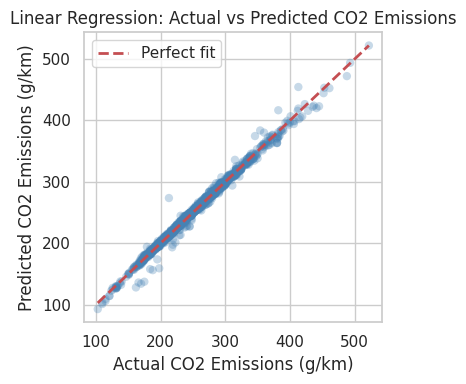

In [80]:
# Plot: Actual vs Predicted
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", edgecolors="none")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Linear Regression: Actual vs Predicted CO2 Emissions")
plt.legend()
plt.tight_layout()
plt.show()

The model captures the relationship as a weighted linear combination of vehicle characteristics:

- Numerical features (engine size, cylinders, transmission gears, fuel-consumption metrics) were standardized.
- Categorical features (make, vehicle class, fuel type, transmission type) were one-hot encoded.
- Linear Regression then learned one coefficient per transformed feature, so each coefficient indicates the direction and strength of its contribution to CO₂ emissions.

From the results, the relationship is modeled very well on this dataset (MAE ≈ 3.19, RMSE ≈ 5.48, R² ≈ 0.9917), and the actual-vs-predicted plot shows points tightly around the 45° line. This indicates emissions are largely explained by these inputs, especially fuel-use-related variables, with category effects captured through encoded group indicators.

9.0 - Question
==============

Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

1. The model appears to perform very strongly on the test split: MAE ≈ 3.19 g/km, RMSE ≈ 5.48 g/km, and R² ≈ 0.9917.
2. MAE means predictions are off by about 3.19 g/km on average, which is small relative to typical CO₂ values, so practical error is low.
3. RMSE is higher than MAE, indicating some larger errors exist, but at ~5.48 g/km they still seem modest; errors are not dominated by extreme misses.
4. R² = 0.9917 means the model explains about 99.17% of emission variance, so the selected features capture most of the signal in this dataset.
5. Reliability is high within this dataset, but should still be treated cautiously: fuel-consumption features are very directly tied to CO₂, and some are highly collinear (for example, L/100 km vs mpg), which can inflate apparent fit quality. To confirm robustness, use k-fold cross-validation and test on a truly unseen dataset/year.

10.0 - Question
=============

Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

PS: Following inference is made using the reference of multiple questions solved above.

The following factors rank highest in their influence on CO₂ emissions:

Primary Drivers (Direct Impact)
 - Fuel Consumption Metrics (strongest) (With reference from Question 4.0)
    - Combined fuel consumption (L/100 km): correlation ≈ 0.91
    - City/Highway fuel consumption: correlation ≈ 0.88–0.91
    - These are almost perfectly collinear with CO₂, as burning fuel directly produces emissions

 - Engine Size (correlation ≈ 0.86) (With reference from Question 4.0)
    - Larger engines consume more fuel and produce proportionally higher emissions
    - Strong cascading effect on fuel consumption behavior

 - Number of Cylinders (correlation ≈ 0.84) (With reference from Question 4.0)
   - More cylinders typically mean greater displacement and fuel consumption
   - Closely tied to engine capacity

 - Make (With reference from Feature importance table from Question 2.0)
   - Shows the Vehicle Make is also an important feature that can impact the CO2 emission
   - Some Vehicle Makers can be more sensitive the CO2 emissions, than others.


Secondary Drivers (Category Effects)
 - Vehicle Class (With reference from Question 5.1)
   - Pickups, Vans, and SUVs emit significantly more (~300–400+ g/km on average)
   - Compact/sedan classes emit substantially less (~180–220 g/km)
   - Weight, aerodynamics, and design all factor into class-level emissions

 - Fuel Type (With reference from Question 5.2)
   - Ethanol and Premium Gasoline vehicles tend to have higher emissions than Regular Gasoline
   - Diesel vehicles show moderate emissions
   - Natural Gas offer lower emission